In [1]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import numpy as np
import pandas as pd
import portfolio_analytics as erk
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
erk.bond_cash_flows(3, 100, 0.03, 2)

1      1.5
2      1.5
3      1.5
4      1.5
5      1.5
6    101.5
dtype: float64

In [4]:
erk.bond_price(20, 1000, 0.05, 2, .04)

np.float64(1136.7773962036904)

In [5]:
erk.bond_price(20, 1000, 0.05, 2, .05)

np.float64(1000.0000000000023)

In [6]:
erk.bond_price(20, 1000, 0.05, 2, .02)

np.float64(1492.520291709342)

In [7]:
rates = np.linspace(0.01, 0.10, num=20)
rates

array([0.01      , 0.01473684, 0.01947368, 0.02421053, 0.02894737,
       0.03368421, 0.03842105, 0.04315789, 0.04789474, 0.05263158,
       0.05736842, 0.06210526, 0.06684211, 0.07157895, 0.07631579,
       0.08105263, 0.08578947, 0.09052632, 0.09526316, 0.1       ])

In [9]:
prices = [erk.bond_price(10, 1000, .05, 2, rate) for rate in rates]
prices

[np.float64(1379.7483829333992),
 np.float64(1326.7629283179222),
 np.float64(1276.1632981372743),
 np.float64(1227.833537616068),
 np.float64(1181.6636507727876),
 np.float64(1137.5492793724407),
 np.float64(1095.3913999300185),
 np.float64(1055.0960377089511),
 np.float64(1016.5739967228162),
 np.float64(979.7406048086303),
 np.float64(944.5154728963505),
 np.float64(910.8222676519945),
 np.float64(878.5884967212596),
 np.float64(847.74530584692),
 np.float64(818.2272871767957),
 np.float64(789.9722981198867),
 np.float64(762.9212901465673),
 np.float64(737.0181469646424),
 np.float64(712.209531536784),
 np.float64(688.4447414365)]

<Axes: title={'center': 'Price of 10 y bond diff interest rates'}>

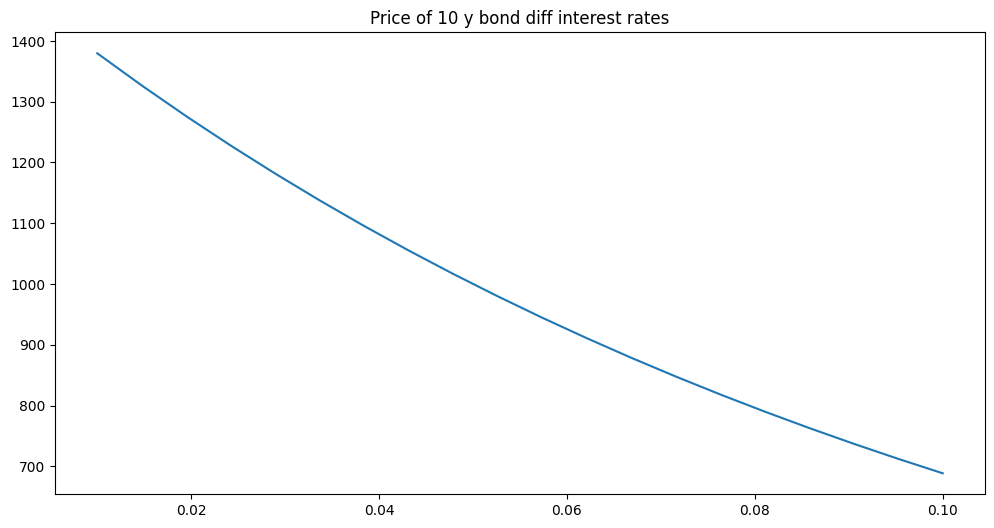

In [11]:
pd.DataFrame(data=prices, index=rates).plot(title="Price of 10 y bond diff interest rates", legend=0, figsize=(12,6))

In [13]:
cf = erk.bond_cash_flows(3, 1000, .06, 2)
cf

1      30.0
2      30.0
3      30.0
4      30.0
5      30.0
6    1030.0
dtype: float64

In [14]:
discounts = erk.discount(cf.index, .06/2)
discounts

Index([ 0.970873786407767, 0.9425959091337544, 0.9151416593531595,
       0.8884870479156888, 0.8626087843841639, 0.8374842566836542],
      dtype='float64')

In [15]:
dcf = discounts*cf
dcf

1     29.126214
2     28.277877
3     27.454250
4     26.654611
5     25.878264
6    862.608784
dtype: float64

In [18]:
weights = dcf/dcf.sum()

In [19]:
weights

1    0.029126
2    0.028278
3    0.027454
4    0.026655
5    0.025878
6    0.862609
dtype: float64

In [22]:
(cf.index*weights).sum

<bound method Series.sum of 1    0.029126
2    0.056556
3    0.082363
4    0.106618
5    0.129391
6    5.175653
dtype: float64>